## Step 1 — Load news dataset and preview

Load the news CSV, normalize column names, parse `date`, and preview rows. File expected at `Data/newsData/raw_analyst_ratings.csv`.


In [16]:
# Step 1: Load news dataset
from pathlib import Path
import pandas as pd

NEWS_PATH = Path("../Data/newsData/raw_analyst_ratings.csv")
if not NEWS_PATH.exists():
    raise FileNotFoundError(f"News CSV not found at {NEWS_PATH.resolve()} — add it and rerun.")

# 'infer_datetime_format' is deprecated, so we drop it
news = pd.read_csv(
    NEWS_PATH,
    parse_dates=['date'],
    low_memory=False
)

# normalize column names
news.columns = [c.strip().lower() for c in news.columns]

print("News shape:", news.shape)
print("Columns:", news.columns.tolist())
news.head(8)


News shape: (1407328, 6)
Columns: ['unnamed: 0', 'headline', 'url', 'publisher', 'date', 'stock']


,unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A
3,3,46 Stocks Moving In Friday's Mid-Day Session,https://www.benzinga.com/news/20/05/16095921/4...,Lisa Levin,2020-05-22 12:45:06-04:00,A
4,4,B of A Securities Maintains Neutral on Agilent...,https://www.benzinga.com/news/20/05/16095304/b...,Vick Meyer,2020-05-22 11:38:59-04:00,A
5,5,"CFRA Maintains Hold on Agilent Technologies, L...",https://www.benzinga.com/news/20/05/16095163/c...,vishwanath@benzinga.com,2020-05-22 11:23:25-04:00,A
6,6,"UBS Maintains Neutral on Agilent Technologies,...",https://www.benzinga.com/news/20/05/16094027/u...,vishwanath@benzinga.com,2020-05-22 09:36:20-04:00,A
7,7,Agilent Technologies shares are trading higher...,https://www.benzinga.com/wiim/20/05/16093805/a...,Benzinga Newsdesk,2020-05-22 09:07:04-04:00,A


## Step 2 — Clean & standardize news data

Ensure required columns (`headline`, `publisher`, `date`, `stock`) exist. Normalize text, drop invalid dates, and create `publish_date` (date-only) for daily alignment.


In [17]:
# Step 2: Clean news
required = ['headline','publisher','date','stock']
missing = [r for r in required if r not in news.columns]
if missing:
    raise KeyError(f"Missing required news columns: {missing}")

news['headline'] = news['headline'].fillna('').astype(str)
news['publisher'] = news['publisher'].fillna('').astype(str)
news['stock'] = news['stock'].fillna('').astype(str)

# ensure datetime column
news['date'] = pd.to_datetime(news['date'], errors='coerce')
if news['date'].isna().any():
    print("Warning: some news rows have invalid dates and will be dropped for alignment.")
news = news.dropna(subset=['date']).copy()

# create publish_date (date-only)
news['publish_date'] = pd.to_datetime(news['date'].dt.date)

print("Cleaned news rows:", len(news))
news[['publish_date','stock','publisher','headline']].head(10)


Cleaned news rows: 55987


,publish_date,stock,publisher,headline
0,2020-06-05,A,Benzinga Insights,Stocks That Hit 52-Week Highs On Friday
1,2020-06-03,A,Benzinga Insights,Stocks That Hit 52-Week Highs On Wednesday
2,2020-05-26,A,Lisa Levin,71 Biggest Movers From Friday
3,2020-05-22,A,Lisa Levin,46 Stocks Moving In Friday's Mid-Day Session
4,2020-05-22,A,Vick Meyer,B of A Securities Maintains Neutral on Agilent...
5,2020-05-22,A,vishwanath@benzinga.com,"CFRA Maintains Hold on Agilent Technologies, L..."
6,2020-05-22,A,vishwanath@benzinga.com,"UBS Maintains Neutral on Agilent Technologies,..."
7,2020-05-22,A,Benzinga Newsdesk,Agilent Technologies shares are trading higher...
8,2020-05-22,A,vishwanath@benzinga.com,Wells Fargo Maintains Overweight on Agilent Te...
9,2020-05-22,A,Lisa Levin,10 Biggest Price Target Changes For Friday


## Step 3 — Sentiment analysis per headline (VADER + TextBlob)

Compute sentiment scores per headline using:
- **VADER** (NLTK) — works well on short, social/headline text.
- **TextBlob** — simpler polarity subjectivity scores.

We add `sent_vader` (compound) and `sent_textblob` (polarity) columns.


In [18]:
# Step 3: Sentiment analysis with VADER and TextBlob
import nltk

# Download required resources
nltk.download('vader_lexicon', quiet=True)
nltk.download('punkt', quiet=True)   # <-- add this line

from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
news['sent_vader'] = news['headline'].apply(
    lambda t: sia.polarity_scores(str(t))['compound']
)

# TextBlob (optional)
try:
    from textblob import TextBlob
    def tb_polarity(text):
        return TextBlob(str(text)).sentiment.polarity
    news['sent_textblob'] = news['headline'].apply(tb_polarity)
    tb_available = True
except Exception as e:
    news['sent_textblob'] = None
    tb_available = False
    print("TextBlob not available; install `textblob` if you want its polarity scores. Error:", e)

# quick check
print("VADER range:", news['sent_vader'].min(), "to", news['sent_vader'].max())
if tb_available:
    print("TextBlob polarity range:", news['sent_textblob'].min(), "to", news['sent_textblob'].max())

# preview results
print(news[['date','stock','headline','sent_vader','sent_textblob']].head(12))


TextBlob not available; install `textblob` if you want its polarity scores. Error: No module named 'textblob'
VADER range: -0.9382 to 0.9666
                          date stock  \
0    2020-06-05 10:30:54-04:00     A   
1    2020-06-03 10:45:20-04:00     A   
2    2020-05-26 04:30:07-04:00     A   
3    2020-05-22 12:45:06-04:00     A   
4    2020-05-22 11:38:59-04:00     A   
5    2020-05-22 11:23:25-04:00     A   
6    2020-05-22 09:36:20-04:00     A   
7    2020-05-22 09:07:04-04:00     A   
8    2020-05-22 08:37:59-04:00     A   
9    2020-05-22 08:06:17-04:00     A   
1433 2020-06-09 10:52:15-04:00    AA   
1434 2020-06-08 11:29:29-04:00    AA   

                                               headline  sent_vader  \
0               Stocks That Hit 52-Week Highs On Friday      0.0000   
1            Stocks That Hit 52-Week Highs On Wednesday      0.0000   
2                         71 Biggest Movers From Friday      0.0000   
3          46 Stocks Moving In Friday's Mid-Day Sessio

## Step 4 — Aggregate daily sentiment per stock

If multiple headlines exist for a (stock, date), compute:
- mean sentiment (VADER and TextBlob)
- median VADER
- article count

Result: DataFrame `daily_sent` with columns `stock, date, sent_vader_mean, sent_textblob_mean, n_articles`.


In [19]:
# Step 4: Aggregate daily sentiment per stock
agg_cols = {}
agg_cols['sent_vader'] = ['mean','median']
if tb_available:
    agg_cols['sent_textblob'] = ['mean']
agg_cols['headline'] = ['count']

# group and flatten columns
grouped = news.groupby(['stock','publish_date']).agg({
    'sent_vader': ['mean','median'],
    'headline': 'count',
    **({'sent_textblob':'mean'} if tb_available else {})
}).reset_index()

# flatten MultiIndex
grouped.columns = ['stock','date'] + ['sent_vader_mean','sent_vader_median','n_articles'] + (['sent_textblob_mean'] if tb_available else [])
# ensure date dtype
grouped['date'] = pd.to_datetime(grouped['date'])

daily_sent = grouped
print("Daily sentiment rows:", daily_sent.shape)
daily_sent.head(10)


Daily sentiment rows: (44196, 5)


,stock,date,sent_vader_mean,sent_vader_median,n_articles
0,A,2020-05-22,0.0480,0.0000,7
1,A,2020-05-26,0.0000,0.0000,1
2,A,2020-06-03,0.0000,0.0000,1
3,A,2020-06-05,0.0000,0.0000,1
4,AA,2020-05-18,0.8519,0.8519,1
5,AA,2020-05-26,-0.1280,-0.1280,1
6,AA,2020-05-27,0.4455,0.4455,2
7,AA,2020-06-03,0.8442,0.8442,1
8,AA,2020-06-04,0.8442,0.8442,1
9,AA,2020-06-05,0.0000,0.0000,1


## Step 5 — Load stock price data (daily OHLCV) for tickers

Use existing in-memory `stock_data` (if you ran previous cells). Otherwise load CSVs from `../Data/yfinance_data/Data/`. Each stock DataFrame must have a daily date index and `close` or `adj close` column.


In [20]:
# Step 5: Load stock CSVs if stock_data not in memory
from pathlib import Path
import pandas as pd

try:
    stock_data  # if preloaded earlier
    print("Using in-memory stock_data dictionary.")
except NameError:
    DATA_DIR = Path("../Data/yfinance_data/Data")
    csvs = sorted(DATA_DIR.glob("*.csv"))
    if not csvs:
        raise FileNotFoundError(f"No price CSVs found in {DATA_DIR.resolve()}")
    stock_data = {}
    for f in csvs:
        dfp = pd.read_csv(f, low_memory=False)
        # normalize and parse date column
        dfp.columns = [c.strip().lower() for c in dfp.columns]
        if 'date' not in dfp.columns:
            # try to rename first column
            dfp.rename(columns={dfp.columns[0]:'date'}, inplace=True)
        dfp['date'] = pd.to_datetime(dfp['date'], errors='coerce')
        dfp = dfp.dropna(subset=['date']).sort_values('date').set_index('date')
        stock_data[f.stem.upper()] = dfp
    print("Loaded tickers:", list(stock_data.keys())[:10])


Using in-memory stock_data dictionary.


## Step 6 — Compute daily returns for each stock

Compute `daily_return` for each stock using `adj close` if available, otherwise `close`. Also create a `trade_date` (date-only) column for merging.


In [21]:
# Step 6: compute daily returns and trade_date
for symbol, sdf in stock_data.items():
    if 'adj close' in sdf.columns:
        sdf['daily_return'] = pd.to_numeric(sdf['adj close'], errors='coerce').pct_change()
    elif 'adj_close' in sdf.columns:
        sdf['daily_return'] = pd.to_numeric(sdf['adj_close'], errors='coerce').pct_change()
    elif 'close' in sdf.columns:
        sdf['daily_return'] = pd.to_numeric(sdf['close'], errors='coerce').pct_change()
    else:
        sdf['daily_return'] = pd.Series(dtype=float)
    # trade_date for merge (date-only)
    sdf['trade_date'] = pd.to_datetime(sdf.index.date)
    stock_data[symbol] = sdf

# Print daily returns and trade_date for all tickers
for symbol, sdf in stock_data.items():
    print(f"\nTicker: {symbol}")
    print(sdf[['daily_return', 'trade_date']].head())  # show first 5 rows for each



Ticker: AAPL
            daily_return trade_date
date                               
2009-01-02           NaN 2009-01-02
2009-01-05      0.042204 2009-01-05
2009-01-06     -0.016494 2009-01-06
2009-01-07     -0.021609 2009-01-07
2009-01-08      0.018570 2009-01-08

Ticker: AMZN
            daily_return trade_date
date                               
2009-01-02           NaN 2009-01-02
2009-01-05     -0.005519 2009-01-05
2009-01-06      0.061043 2009-01-06
2009-01-07     -0.020223 2009-01-07
2009-01-08      0.017082 2009-01-08

Ticker: GOOG
            daily_return trade_date
date                               
2009-01-02           NaN 2009-01-02
2009-01-05      0.020945 2009-01-05
2009-01-06      0.018321 2009-01-06
2009-01-07     -0.036071 2009-01-07
2009-01-08      0.009875 2009-01-08

Ticker: META
            daily_return trade_date
date                               
2012-05-18           NaN 2012-05-18
2012-05-21     -0.109861 2012-05-21
2012-05-22     -0.089039 2012-05-22
2012-05-

## Step 7 — Merge daily sentiment with stock returns for one ticker

Select a ticker (e.g., AAPL). Merge `daily_sent` (for that stock) with that stock's `trade_date` returns by date. Then compute Pearson correlation (same-day) and lagged correlation (sentiment today vs next-day return).


In [22]:
# Step 7: merge and correlation for all tickers
import numpy as np
from scipy.stats import pearsonr

for ticker in stock_data.keys():
    print("\nTicker selected:", ticker)

    # filter daily_sent for ticker (case-insensitive)
    ds = daily_sent[daily_sent['stock'].str.upper() == ticker.upper()].copy()
    if ds.empty:
        print("No news for ticker:", ticker)
        continue

    # prepare returns DF
    sdf = stock_data[ticker].reset_index()[['trade_date','daily_return']].dropna()
    sdf = sdf.rename(columns={'trade_date':'date'})

    # merge sentiment with returns
    merged = pd.merge(ds.rename(columns={'date':'date'}), sdf, on='date', how='inner')
    print("Merged rows:", len(merged))
    if not merged.empty:
        print(merged.head())

    # same-day correlation
    if len(merged) >= 5:
        r_same, p_same = pearsonr(merged['sent_vader_mean'], merged['daily_return'])
        print(f"Pearson r (same-day VADER mean vs same-day return) = {r_same:.4f}, p = {p_same:.4g}")
    else:
        print("Not enough same-day samples to compute reliable correlation (need >=5).")

    # lagged correlation: sentiment today → next-day return
    merged['next_return'] = merged['daily_return'].shift(-1)
    merged_lag = merged.dropna(subset=['next_return','sent_vader_mean'])
    if len(merged_lag) >= 5:
        r_lag, p_lag = pearsonr(merged_lag['sent_vader_mean'], merged_lag['next_return'])
        print(f"Pearson r (VADER mean today vs next-day return) = {r_lag:.4f}, p = {p_lag:.4g}")
    else:
        print("Not enough lagged samples to compute reliable correlation.")



Ticker selected: AAPL
Merged rows: 2
  stock       date  sent_vader_mean  sent_vader_median  n_articles  \
0  AAPL 2020-06-09          0.24690            0.22020           4   
1  AAPL 2020-06-10          0.19885            0.12695           6   

   daily_return  
0      0.031578  
1      0.025728  
Not enough same-day samples to compute reliable correlation (need >=5).
Not enough lagged samples to compute reliable correlation.

Ticker selected: AMZN
Merged rows: 2
  stock       date  sent_vader_mean  sent_vader_median  n_articles  \
0  AMZN 2020-06-09         0.077775            0.25530           4   
1  AMZN 2020-06-10         0.391233            0.37985           6   

   daily_return  
0      0.030427  
1      0.017913  
Not enough same-day samples to compute reliable correlation (need >=5).
Not enough lagged samples to compute reliable correlation.

Ticker selected: GOOG
Merged rows: 5
  stock       date  sent_vader_mean  sent_vader_median  n_articles  \
0  GOOG 2020-06-04      

## Step 8 — Batch correlation across all tickers with news

Loop through all tickers where `daily_sent` exists, compute same-day and lagged correlations (only when there are ≥ 5 overlapping days). Summarize results in a DataFrame `corr_df`.


In [23]:
# Step 8: batch correlations
results = []
for ticker in sorted(stock_data.keys()):
    ds = daily_sent[daily_sent['stock'].str.upper() == ticker.upper()].copy()
    if ds.empty:
        continue
    sdf = stock_data[ticker].reset_index()[['trade_date','daily_return']].dropna()
    sdf = sdf.rename(columns={'trade_date':'date'})
    merged = pd.merge(ds.rename(columns={'date':'date'}), sdf, on='date', how='inner')
    if len(merged) < 5:
        continue
    # same-day using VADER mean
    try:
        r_same, p_same = pearsonr(merged['sent_vader_mean'], merged['daily_return'])
    except Exception:
        r_same, p_same = (np.nan, np.nan)
    # lagged
    merged['next_return'] = merged['daily_return'].shift(-1)
    merged_lag = merged.dropna(subset=['next_return','sent_vader_mean'])
    if len(merged_lag) >= 5:
        r_lag, p_lag = pearsonr(merged_lag['sent_vader_mean'], merged_lag['next_return'])
    else:
        r_lag, p_lag = (np.nan, np.nan)
    results.append({'ticker':ticker, 'n_days':len(merged), 'r_same':r_same, 'p_same':p_same, 'r_lag':r_lag, 'p_lag':p_lag})

corr_df = pd.DataFrame(results).sort_values(by='r_lag', key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
print("Correlation summary (top rows):")
corr_df.head(20)


Correlation summary (top rows):


,ticker,n_days,r_same,p_same,r_lag,p_lag
0,GOOG,5,-0.234365,0.704352,NaN,NaN


## Step 9 — Visualize sentiment vs returns for a ticker

Plot daily aggregated sentiment (VADER mean) and daily returns together for a visual inspection of relationship.


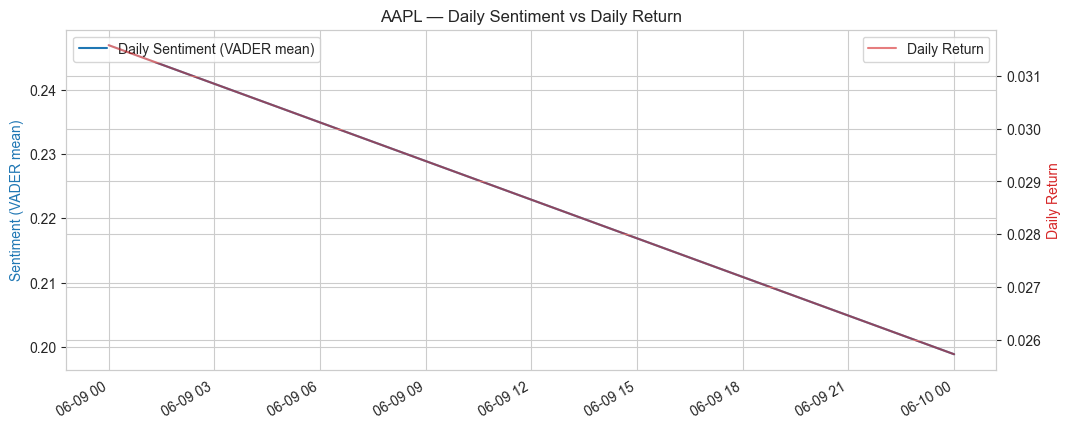

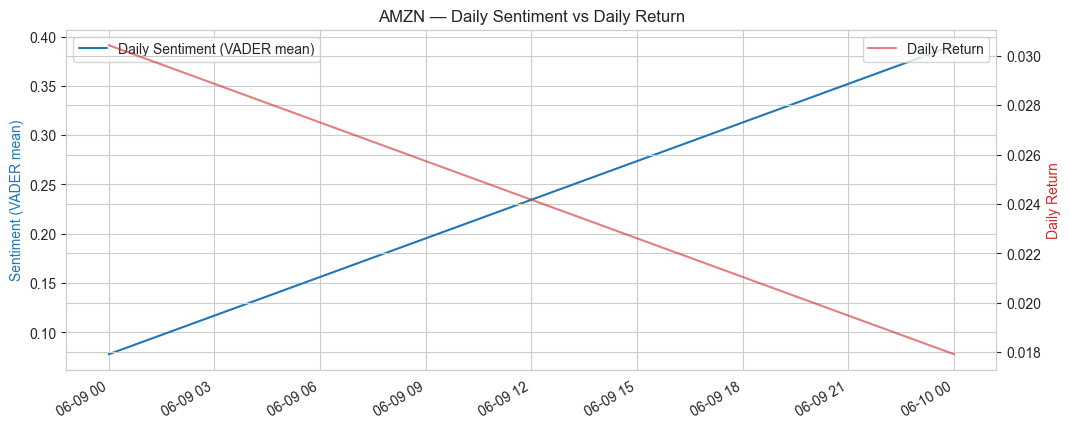

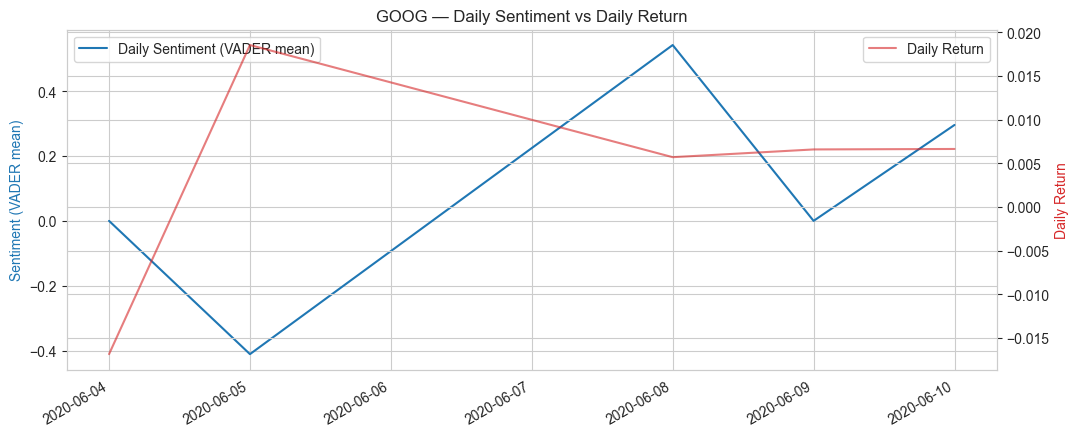

No merged data to plot for META
No merged data to plot for MSFT


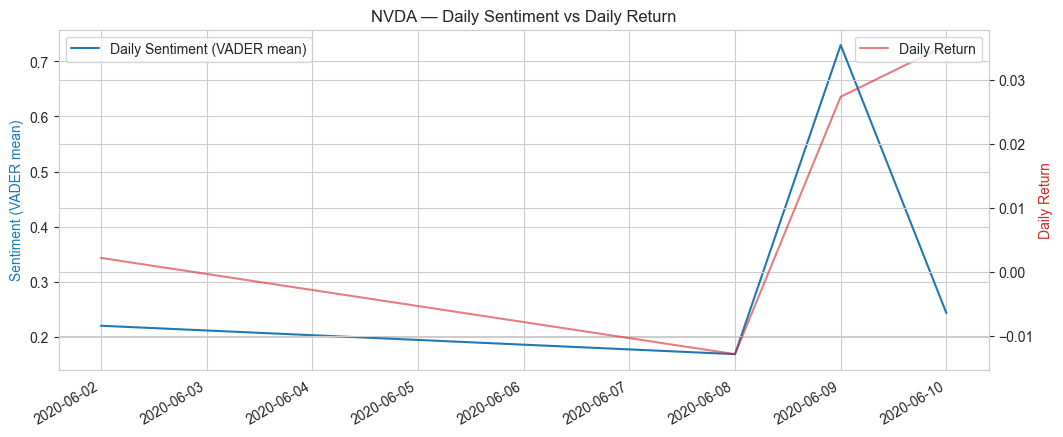

In [24]:
# Step 9: visualization for all tickers
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

for ticker in stock_data.keys():
    # filter sentiment for ticker
    ds = daily_sent[daily_sent['stock'].str.upper() == ticker.upper()].copy()
    # prepare returns DF
    sdf = stock_data[ticker].reset_index()[['trade_date','daily_return']].dropna()
    sdf = sdf.rename(columns={'trade_date':'date'})
    # merge sentiment with returns
    merged = pd.merge(ds.rename(columns={'date':'date'}), sdf, on='date', how='inner').sort_values('date')

    if merged.empty:
        print("No merged data to plot for", ticker)
        continue

    # plot
    fig, ax1 = plt.subplots(figsize=(12,5))
    ax1.plot(merged['date'], merged['sent_vader_mean'], color='tab:blue', label='Daily Sentiment (VADER mean)')
    ax1.set_ylabel('Sentiment (VADER mean)', color='tab:blue')
    ax2 = ax1.twinx()
    ax2.plot(merged['date'], merged['daily_return'], color='tab:red', label='Daily Return', alpha=0.6)
    ax2.set_ylabel('Daily Return', color='tab:red')
    ax1.set_title(f"{ticker} — Daily Sentiment vs Daily Return")
    fig.autofmt_xdate()
    ax1.legend(loc='upper left')
    ax2.legend(loc='upper right')
    plt.show()
